In [9]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import XGate
from qiskit_aer import AerSimulator
from shift_operators import ShiftDown, ShiftUp

In [ ]:
def prepare_k_register(deltas):
    r"""Prepares k register into state Σ sqrt(omega_i) |i> where omega_i is inversely proportional to the square
        of the grid spacing of the i'th dimension.
    
    Args:
        deltas (list[float]): The grid spacings for each dimension.
    
    Returns:
        qiskit.circuit.Instruction: An instruction that performs the desired state preparation.
    """
    k = int(np.ceil(np.log2(len(deltas))))
    omegas_non_normalized = 4 / np.array(deltas) ** 2
    omegas = omegas_non_normalized / np.sum(omegas_non_normalized)
    even = np.sum(omegas[::2])

    qc = QuantumCircuit(k)
    theta0 = 2 * np.arccos(np.sqrt(even))
    qc.ry(theta0, 0)

    if k == 2:
        qc.cry(2 * np.arccos(np.sqrt(omegas[0] / even)), *qc.qubits, ctrl_state=0)
        qc.cry(2 * np.arccos(np.sqrt(omegas[1] / (1 - even))), *qc.qubits)

    instr = qc.to_instruction(label="prep_k")
    instr_inv = instr.inverse()
    instr_inv.label = "prep_k_inv"
    
    return instr, instr_inv

def generate_laplacian_block_encoding(nqs, deltas=None, bcs=None):
    r"""Build the quantum circuit for the block encoding of an N-dimensional Laplacian operator
    
    Args:
        nqs (list[int]): Number of qubits per dimensions. Corresponds to 2**nq grid points per dimension.
        deltas (list[float]): Grid spacings for each dimension.
        bcs (list[str]): Boundary conditions of the laplacian. Each item in the list is either "periodic"
            or "dirichlet". The length of the list determines the number of dimensions.
            
    Returns:
        qiskit.QuantumCircuit: Circuit that block encodes the desired Laplacian operator.
    """
    if deltas is None:
        deltas = [1.0] * len(nqs)

    if bcs is None:
        bcs = ["dirichlet"] * len(nqs)

    if len(list(filter(lambda x: x != "dirichlet" and x != "periodic", bcs))) != 0:
        raise ValueError("Invalid boundary conditions")
    
    d = len(nqs)
    k = int(np.ceil(np.log2(d)))
    
    # Defining registers
    l_reg = QuantumRegister(2, "l")
    dirichlet_reg = QuantumRegister(1, "dir")
    j_regs = [QuantumRegister(nqs[i], f"j^{{({i})}}") for i in range(d)]
    k_reg = QuantumRegister(k, "k")


    if k == 0:
        qc = QuantumCircuit(*j_regs, dirichlet_reg, l_reg)

        qc.h(l_reg)
        qc.z(l_reg)

        # Apply dirichlet extra gates if BC is Dirichlet
        if bcs[0] == "dirichlet":
            cx0 = XGate().control(nqs[0]+2, ctrl_state="0" * (nqs[0] + 2))
            cx1 = XGate().control(nqs[0]+2, ctrl_state="1" * (nqs[0] + 2))

            qc.append(cx0, j_regs[0][:] + l_reg[:] + dirichlet_reg[:])
            qc.append(cx1, j_regs[0][:] + l_reg[:] + dirichlet_reg[:])


        # Apply shift operators
        csu = ShiftUp(nqs[0]).control(1)
        csd = ShiftDown(nqs[0]).control(1, ctrl_state=0)
        
        qc.append(csd, [l_reg[1]] + j_regs[0][:])
        qc.append(csu, [l_reg[0]] + j_regs[0][:])

        qc.h(l_reg)
        qc.save_unitary()

    elif k > 2:
        raise NotImplementedError(f"{d}-dimensional Laplacian not implemented yet.")

    else:
        qc = QuantumCircuit(*j_regs, dirichlet_reg, l_reg, k_reg)

        k_prep, k_prep_inv = prepare_k_register(deltas)
        qc.append(k_prep, k_reg)
        qc.h(l_reg)
        qc.z(l_reg)
        qc.barrier()
        
        for i in range(d):
            # Control bitstring for k register
            k_ctrl = bin(i)[2:].zfill(k)

            # Apply dirichlet extra gates if current BC is Dirichlet
            if bcs[i] == "dirichlet":
                cx0 = XGate().control(nqs[i] + k + 2, ctrl_state=k_ctrl + "0" * (nqs[i] + 2))
                cx1 = XGate().control(nqs[i] + k + 2, ctrl_state=k_ctrl + "1" * (nqs[i] + 2))

                qc.append(cx0, j_regs[i][:] + l_reg[:] +  k_reg[:] + dirichlet_reg[:])
                qc.append(cx1, j_regs[i][:] + l_reg[:] +  k_reg[:] + dirichlet_reg[:])


            # Apply shift operators
            csu = ShiftUp(nqs[i]).control(k + 1, ctrl_state=k_ctrl + "1")
            csd = ShiftDown(nqs[i]).control(k + 1, ctrl_state=k_ctrl + "0")

            qc.append(csd, [l_reg[1]] + k_reg[:] + j_regs[i][:])
            qc.append(csu, [l_reg[0]] + k_reg[:] + j_regs[i][:])
            qc.barrier()


        qc.h(l_reg)
        qc.append(k_prep_inv, k_reg)
        qc.save_unitary()

    return qc

def get_circuit_unitary(qc, nqs):
    r"""Build the matrix representation of a quantum circuit block encoding a Laplacian.
    
    Args:
        qc (qiskit.QuantumCircuit): The quantum circuit that block encodes a Laplacian.
        nqs (list[int]): Number of qubits per dimensions. Corresponds to 2**nq grid points per dimension.
    
    Returns:
        a numpy.array representation of the block encoded Laplacian matrix.
    """
    simulator = AerSimulator(method="unitary")
    qc = transpile(qc, simulator)

    result = simulator.run(qc).result()
    unitary = result.get_unitary(qc).data.real
    unitary_subspace = unitary[:2 ** sum(nqs), :2 ** sum(nqs)]

    return unitary_subspace

def plot_heatmap(nqs, deltas=None, bcs=None, ncs=51, vmax=1.0):
    r"""Plot the matrix elements for a Laplacian operator.
    
    Args:
        nqs (list[int]): Number of qubits per dimensions. Corresponds to 2**nq grid points per dimension.
        deltas (list[float]): Grid spacings for each dimension.
        bcs (list[str]): Boundary conditions of the Laplacian.
        ncs (int): Number of colors to use in the plot.
        vmax (float): Color scaling set to -vmax to vmax.
    """
    qc = generate_laplacian_block_encoding(nqs, deltas, bcs)
    unitary = get_circuit_unitary(qc, nqs)
    cmap = plt.get_cmap("seismic", ncs)

    plt.imshow(unitary, cmap=cmap, vmin=-vmax, vmax=vmax)
    plt.colorbar()
    plt.show()



['periodic']


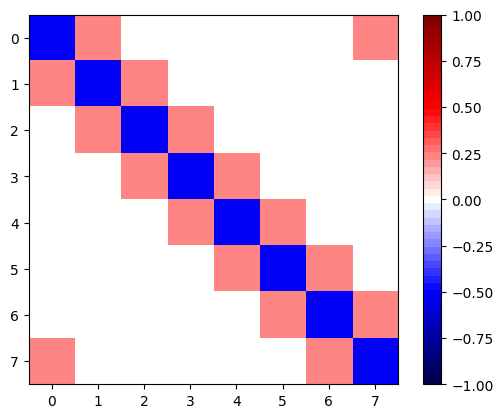

['periodic', 'periodic']


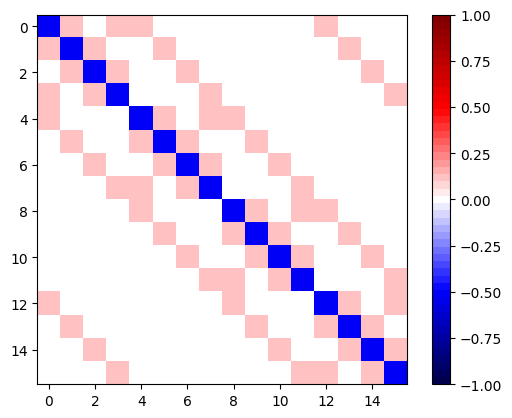

['periodic', 'periodic', 'periodic']


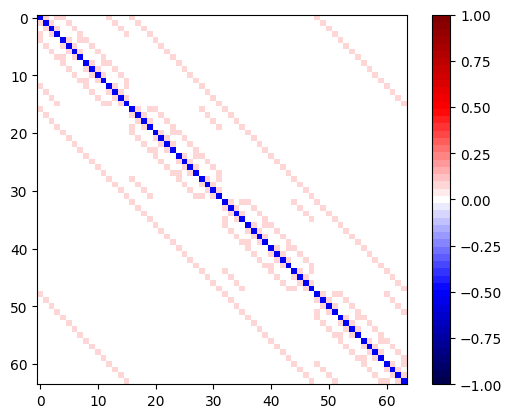

In [46]:
bcs = ["periodic"]
print(bcs)
plot_heatmap([3], bcs=bcs)

bcs = ["periodic", "periodic"]
print(bcs)
plot_heatmap([2, 2], bcs=bcs)

bcs = ["periodic", "periodic", "periodic"]
print(bcs)
plot_heatmap([2, 2, 2], bcs=bcs)

['dirichlet']


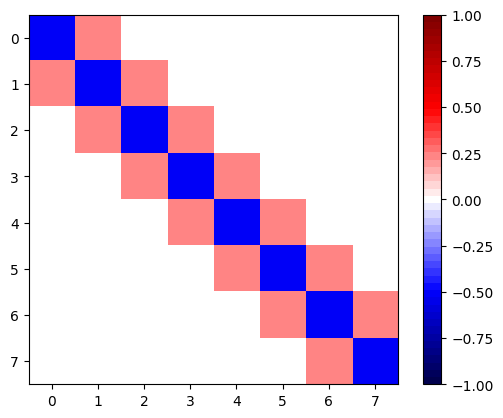

['dirichlet', 'periodic']


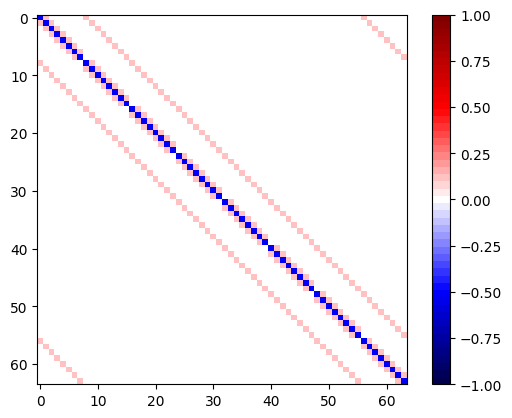

['periodic', 'dirichlet']


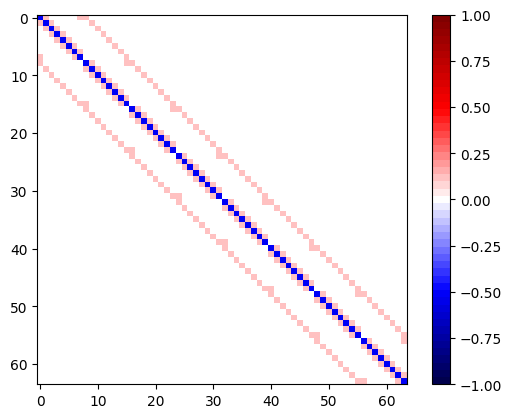

['dirichlet', 'dirichlet']


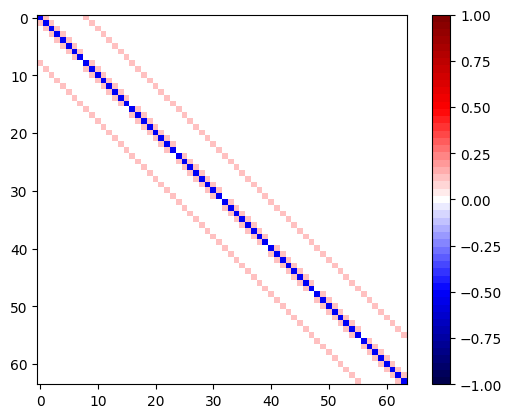

['dirichlet', 'dirichlet', 'dirichlet']


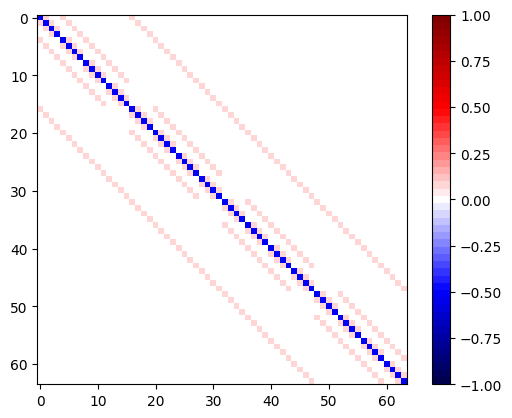

['periodic', 'dirichlet', 'periodic']


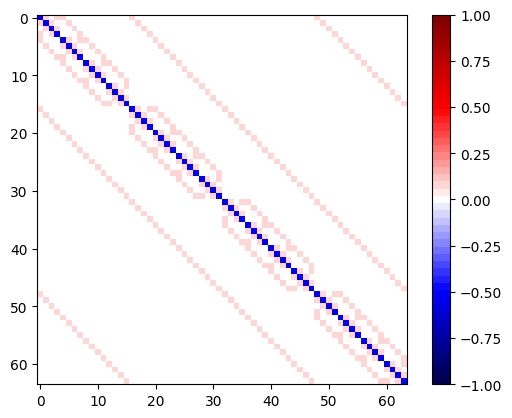

['dirichlet', 'periodic', 'dirichlet']


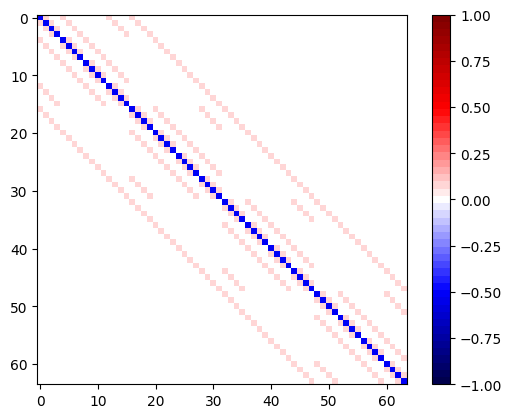

In [51]:
# Dirichlet BC and higher dimensions
bcs = ["dirichlet"]
print(bcs)
plot_heatmap([3], bcs=bcs)

bcs = ["dirichlet", "periodic"]
print(bcs)
plot_heatmap([3, 3], bcs=bcs)

bcs = ["periodic", "dirichlet"]
print(bcs)
plot_heatmap([3, 3], bcs=bcs)

bcs = ["dirichlet", "dirichlet"]
print(bcs)
plot_heatmap([3, 3], bcs=bcs)

bcs = ["dirichlet", "dirichlet", "dirichlet"]
print(bcs)
plot_heatmap([2, 2, 2], bcs=bcs)

bcs = ["periodic", "dirichlet", "periodic"]
print(bcs)
plot_heatmap([2, 2, 2], bcs=bcs)

bcs = ["dirichlet", "periodic", "dirichlet"]
print(bcs)
plot_heatmap([2, 2, 2], bcs=bcs)

nqs: [3, 3] 
deltas: [1.0, 0.5] 
bcs: ['periodic', 'dirichlet']


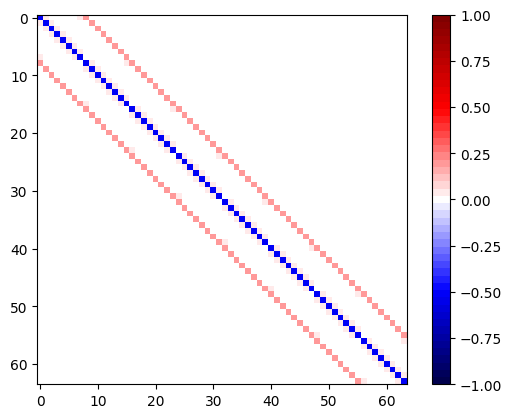

nqs: [3, 3] 
deltas: [0.7, 0.5] 
bcs: ['periodic', 'periodic']


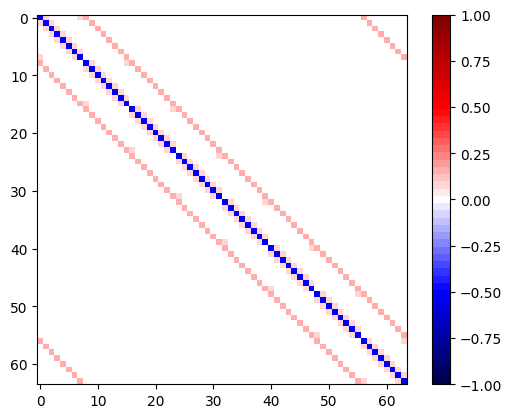

nqs: [1, 2, 3] 
deltas: [0.7, 0.6, 0.5] 
bcs: ['periodic', 'dirichlet', 'periodic']


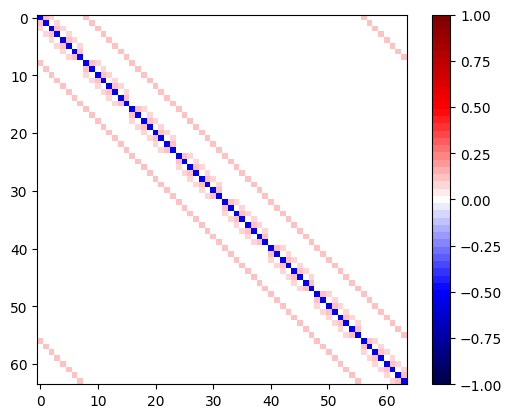

In [64]:
# Varying grid spacings between each dimensions and qubit count
nqs = [3, 3]
deltas = [1.0, 0.5]
bcs = ["periodic", "dirichlet"]
print("nqs:", nqs, "\ndeltas:", deltas, "\nbcs:", bcs)
plot_heatmap(nqs, deltas=deltas, bcs=bcs)

nqs = [3, 3]
deltas = [0.7, 0.5]
bcs = ["periodic", "periodic"]
print("nqs:", nqs, "\ndeltas:", deltas, "\nbcs:", bcs)
plot_heatmap(nqs, deltas=deltas, bcs=bcs)

nqs = [1, 2, 3]
deltas = [0.7, 0.5]
bcs = ["periodic", "dirichlet", "periodic"]
deltas = [0.7, 0.6, 0.5]
print("nqs:", nqs, "\ndeltas:", deltas, "\nbcs:", bcs)
plot_heatmap(nqs, deltas=deltas, bcs=bcs)
